# Table of Contents

1. [Introduction](#1.-Introduction)

2. [Import Libraries And Loading ETS Forecast](#2.-Import-Libraries-And-Loading-ETS-Forecast)

3. [Scenario Design](#3.-Scenario-Design)

4. [Scenario Calculation](#4.-Scenario-Calculation)

5. [Scenario Visualizations](#5.-Scenario-Visualizations)

6. [Impact Summary](#6.-Impact-Summary)

7. [Week 5 Conclusion](#7.-Week-5-Conclusion)

# 1. Introduction

This notebook explores possible future greenhouse gas emission pathways under different policy scenarios.

Instead of generating new forecasts, the ETS(A,Ad,N) baseline forecast developed in Week 4 is modified to simulate the impact of emission reduction policies. These scenarios provide an illustrative comparison of how different mitigation strategies may influence future CO₂ emissions.

# 2. Import Libraries And Loading ETS Forecast

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

ghg_features = pd.read_csv(
    "data/ghg_features.csv"
)

ets_forecast = pd.read_csv(
    "data/ets_forecasts.csv"
)



scenario_data = ets_forecast[
    (ets_forecast["Year"] >= 2025)
    &
    (ets_forecast["Year"] <= 2040)
].copy()



# 3. Scenario Design


Scenario analysis explores how different policy interventions may influence future CO₂ emissions. Instead of generating new forecasts, the ETS(A,Ad,N) baseline forecast from Week 4 is modified under different mitigation assumptions.

Three scenarios are considered:

### Scenario A: Business As Usual (BAU)
- Assumes no additional climate policies.
- Uses the original ETS(A,Ad,N) forecast without modification.

### Scenario B: Moderate Mitigation
- Assumes emission reduction policies gradually reduce emissions.
- Applies a compounded annual reduction of **2%** beginning in 2025.

### Scenario C: Aggressive Mitigation
- Assumes stronger climate interventions.
- Applies a compounded annual reduction of **5%** beginning in 2025.

These scenarios are illustrative and are intended to compare possible emission pathways rather than provide policy-calibrated forecasts.

# 4. Scenario Calculation

In [8]:
scenario_rows = []

for country in scenario_data["Country"].unique():

    country_forecast = (
        scenario_data[
            scenario_data["Country"] == country
        ]
        .sort_values("Year")
        .reset_index(drop=True)
    )

    for _, row in country_forecast.iterrows():

        year = row["Year"]
        forecast = row["Forecast_CO2"]

        # Years since mitigation begins
        years_after_2025 = year - 2025

        # -------------------------
        # Business As Usual
        # -------------------------

        bau = forecast

        # -------------------------
        # Moderate (-2%)
        # -------------------------

        moderate = forecast * (0.98 ** years_after_2025)

        # -------------------------
        # Aggressive (-5%)
        # -------------------------

        aggressive = forecast * (0.95 ** years_after_2025)

        scenario_rows.append(
            [country, year, "BAU", bau]
        )

        scenario_rows.append(
            [country, year, "Moderate", moderate]
        )

        scenario_rows.append(
            [country, year, "Aggressive", aggressive]
        )


scenario_df = pd.DataFrame(

    scenario_rows,

    columns=[
        "Country",
        "Year",
        "Scenario",
        "CO2_Projected"
    ]
)

scenario_df.head()

,Country,Year,Scenario,CO2_Projected
0,Australia,2025,BAU,417.515405
1,Australia,2025,Moderate,417.515405
2,Australia,2025,Aggressive,417.515405
3,Australia,2026,BAU,418.712722
4,Australia,2026,Moderate,410.338468


In [9]:
scenario_df.to_csv(
    "data/scenario_projections.csv",
    index=False
)

print("Scenario dataset saved successfully.")

Scenario dataset saved successfully.


# 5. Scenario Visualizations



To compare different emission pathways, the three policy scenarios are visualized alongside historical CO₂ emissions.

Each chart includes:

- Historical CO₂ emissions (1990–2024)
- Business As Usual (BAU) forecast
- Moderate Mitigation Scenario
- Aggressive Mitigation Scenario
- 1990 emission level as a reference benchmark

These visualizations illustrate how different mitigation strategies influence long-term emission trajectories.

In [19]:
historical = ghg_features[
    ghg_features["year"] <= 2024
].copy()

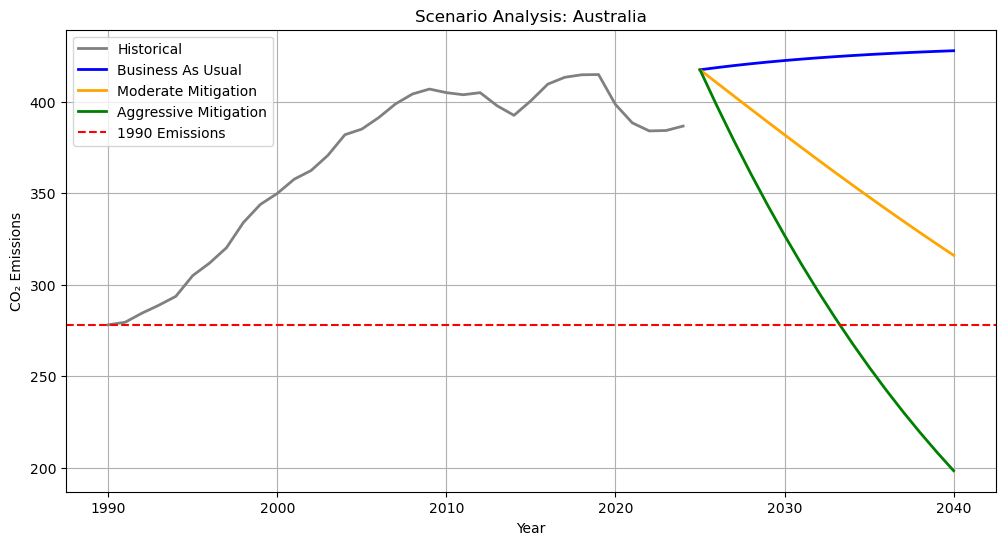

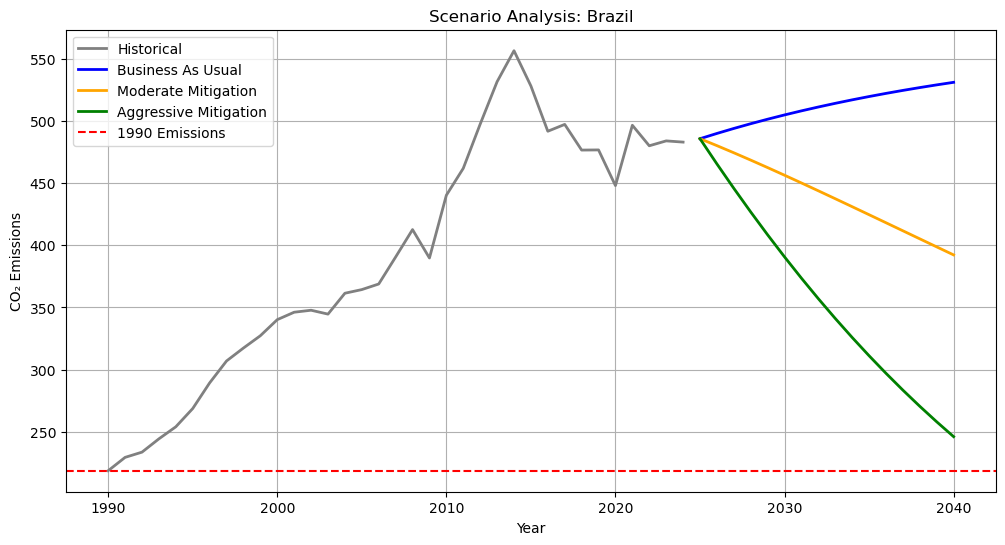

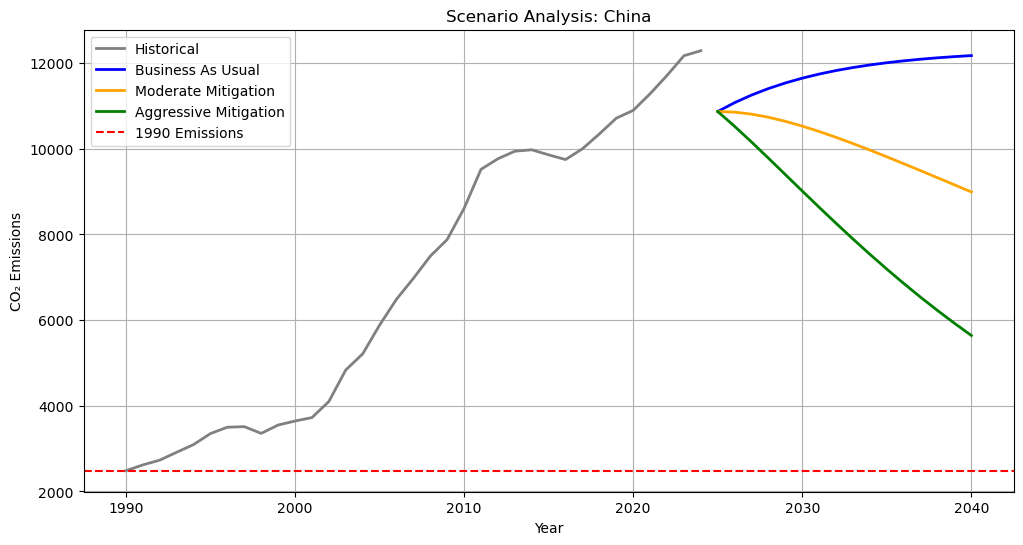

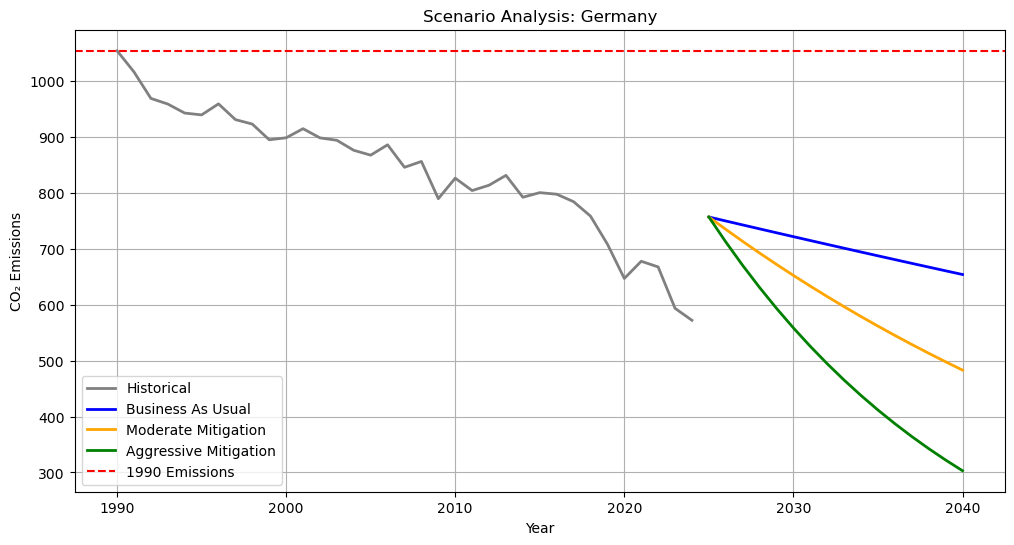

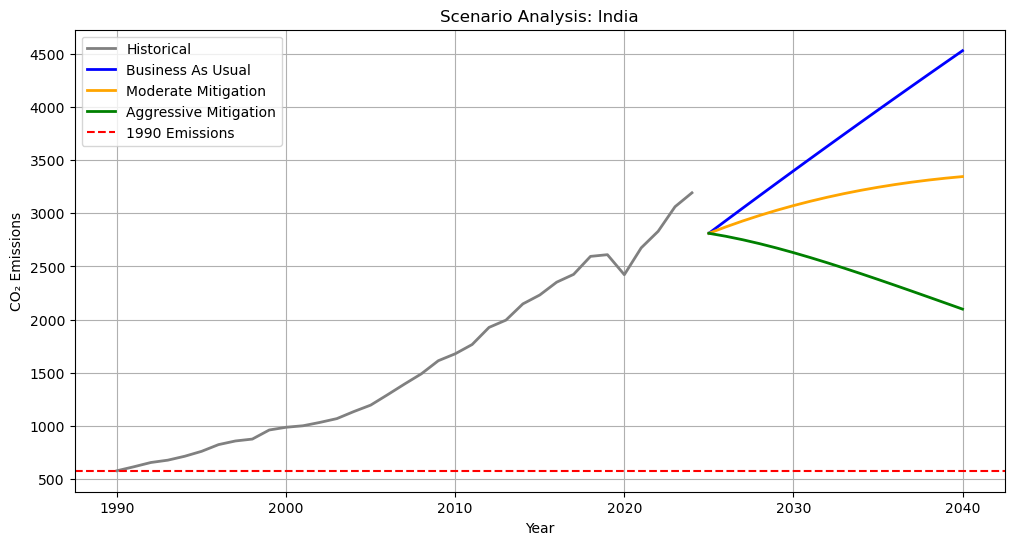

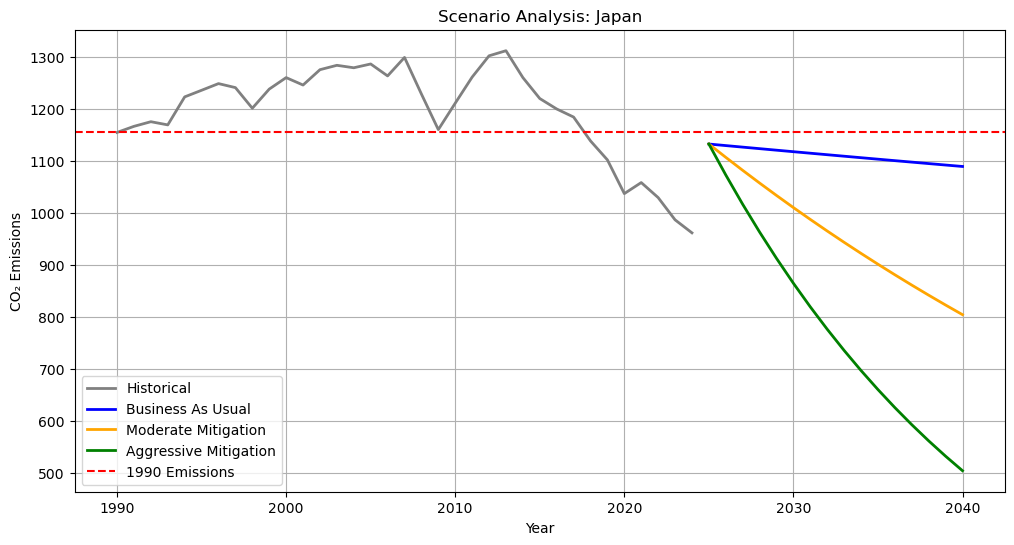

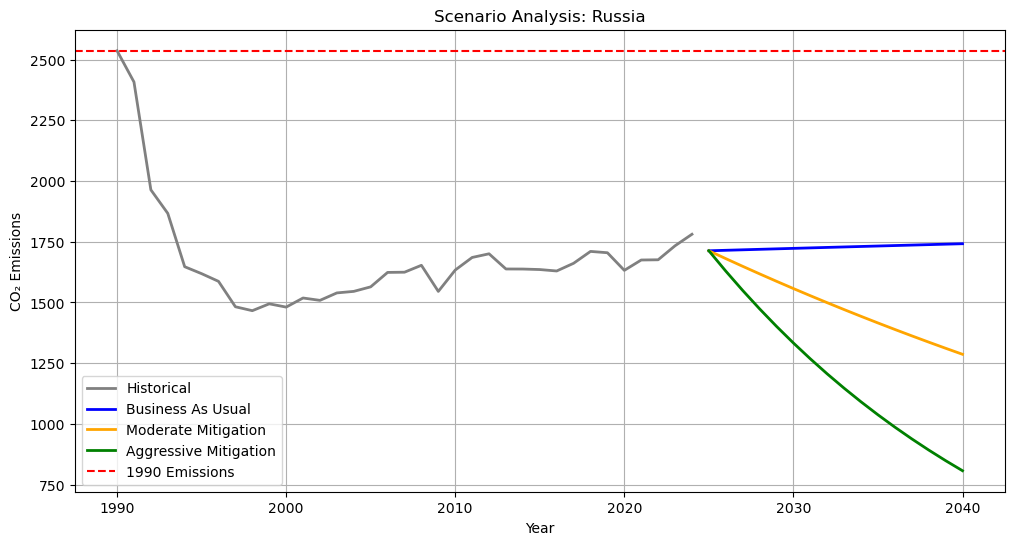

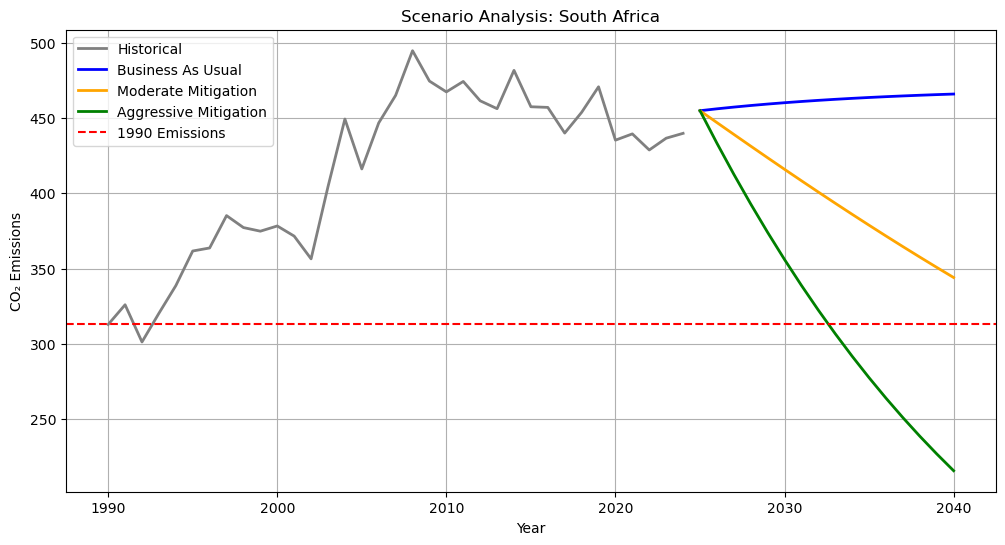

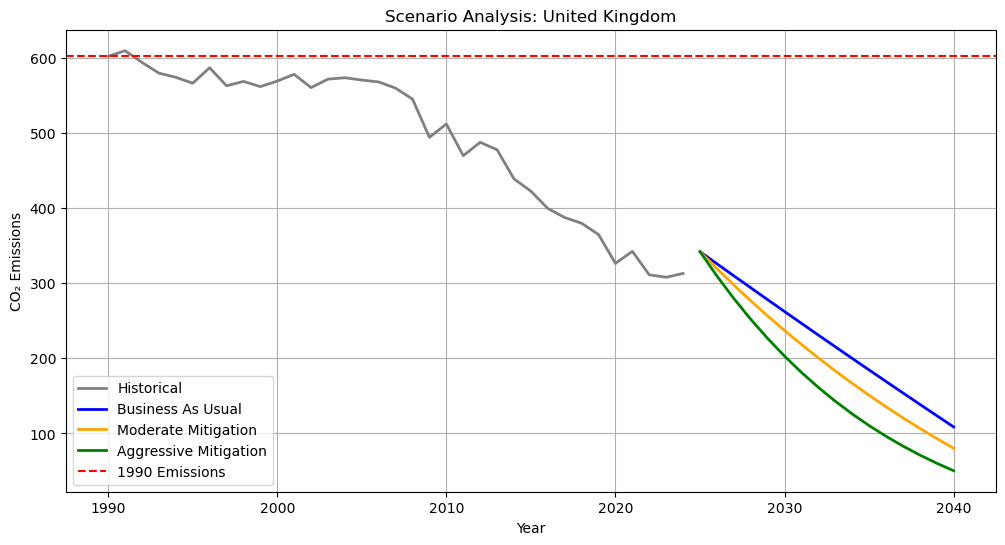

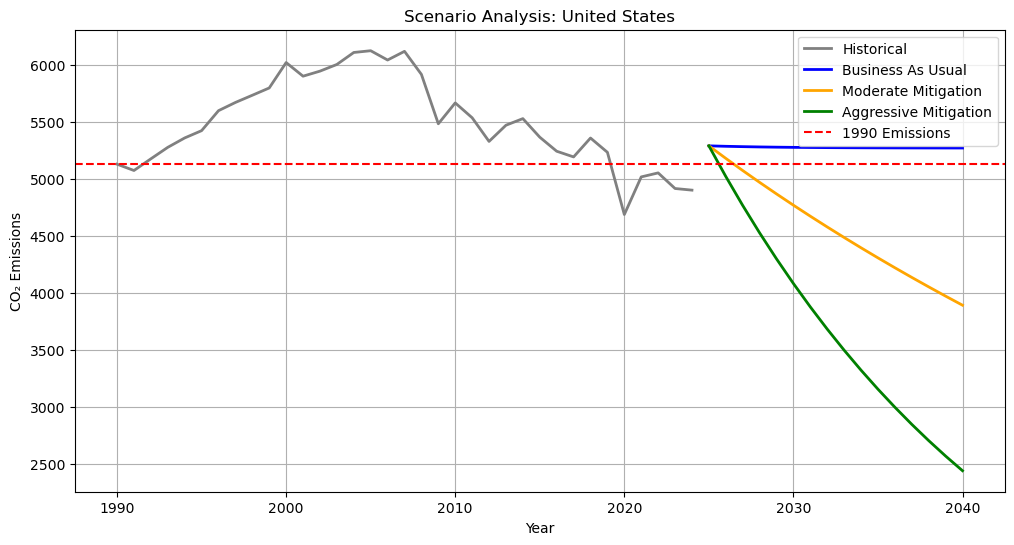

In [33]:
for country in scenario_df["Country"].unique():

    plt.figure(figsize=(12,6))

    colors = {
    "BAU": "blue",
    "Moderate": "orange",
    "Aggressive": "green"
}

    # -----------------------------
    # Historical Data
    # -----------------------------

    hist = historical[
        historical["country"] == country
    ]

    plt.plot(

        hist["year"],

        hist["co2"],

        color="grey",

        linewidth=2,

        label="Historical"

    )


    # -----------------------------
    # BAU
    # -----------------------------

    bau = scenario_df[
        (scenario_df["Country"] == country)
        &
        (scenario_df["Scenario"] == "BAU")
    ]

    plt.plot(

        bau["Year"],

        bau["CO2_Projected"],

        color="blue",

        linewidth=2,

        label="Business As Usual"

    )


    # -----------------------------
    # Moderate
    # -----------------------------

    moderate = scenario_df[
        (scenario_df["Country"] == country)
        &
        (scenario_df["Scenario"] == "Moderate")
    ]

    plt.plot(

        moderate["Year"],

        moderate["CO2_Projected"],

        color="orange",

        linewidth=2,

        label="Moderate Mitigation"

    )


    # -----------------------------
    # Aggressive
    # -----------------------------

    aggressive = scenario_df[
        (scenario_df["Country"] == country)
        &
        (scenario_df["Scenario"] == "Aggressive")
    ]

    plt.plot(

        aggressive["Year"],

        aggressive["CO2_Projected"],

        color="green",

        linewidth=2,

        label="Aggressive Mitigation"

    )


    # -----------------------------
    # 1994 Reference
    # -----------------------------

    reference = hist[hist["year"] == 1990]["co2"].iloc[0]

    plt.axhline(
        y=reference,
        linestyle="--",
        color="red",
        label="1990 Emissions"
)


    plt.title(f"Scenario Analysis: {country}")

    plt.xlabel("Year")

    plt.ylabel("CO₂ Emissions")

    plt.legend()

    plt.grid(True)

    plt.show()

# 6. Impact Summary



To evaluate the long-term effect of different mitigation strategies, cumulative CO₂ emissions are calculated for each country from 2025 to 2040.

Instead of comparing individual years, cumulative emissions measure the total amount of CO₂ emitted over the forecasting period. This provides a clearer understanding of the overall environmental impact of each scenario.

In [34]:
impact_summary = (
    scenario_df
    .groupby(
        ["Country", "Scenario"]
    )["CO2_Projected"]
    .sum()
    .reset_index()
)

impact_summary.rename(
    columns={
        "CO2_Projected": "Cumulative_CO2"
    },
    inplace=True
)

impact_summary.head()

,Country,Scenario,Cumulative_CO2
0,Australia,Aggressive,4736.765411
1,Australia,BAU,6780.277164
2,Australia,Moderate,5848.223700
3,Brazil,Aggressive,5686.669895
4,Brazil,BAU,8177.970930


<Figure size 1400x600 with 0 Axes>

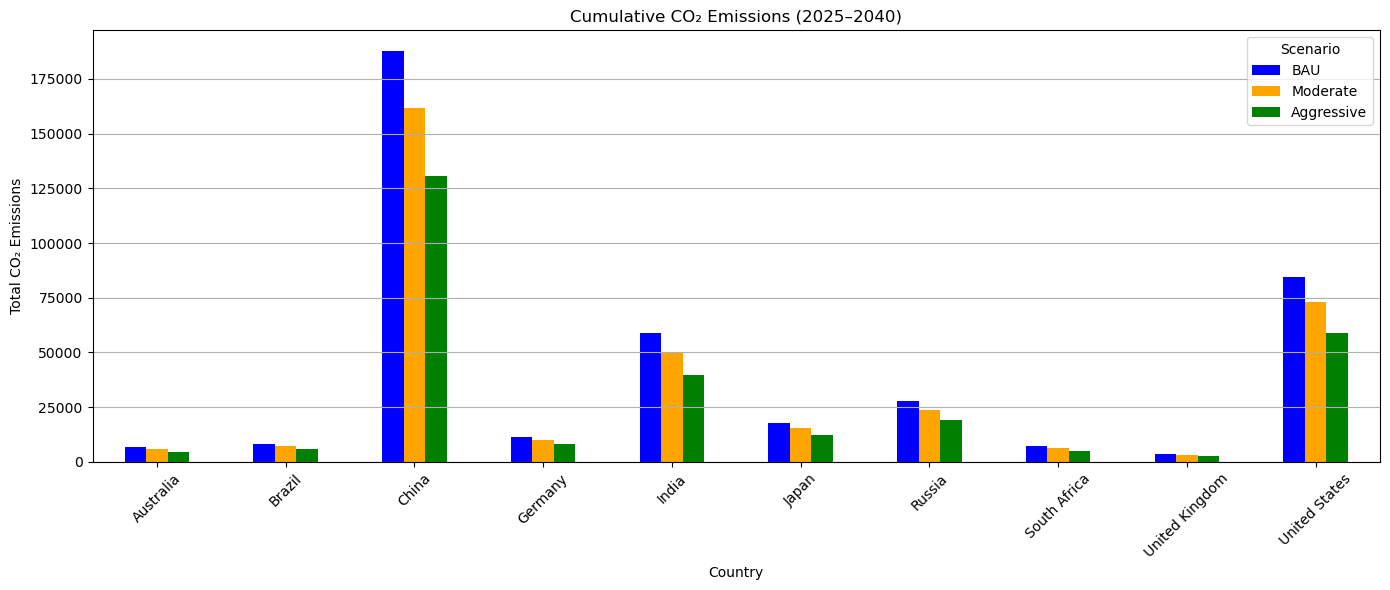

In [39]:
plt.figure(figsize=(14,6))



pivot = impact_summary.pivot(
    index="Country",
    columns="Scenario",
    values="Cumulative_CO2"
)

# Arrange columns in the desired order
pivot = pivot[
    ["BAU", "Moderate", "Aggressive"]
]

pivot.plot(
    kind="bar",
    figsize=(14,6),
    color=[
        "blue",      # BAU
        "orange",    # Moderate
        "green"      # Aggressive
    ]
)

plt.title(
    "Cumulative CO₂ Emissions (2025–2040)"
)

plt.ylabel("Total CO₂ Emissions")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.legend(title="Scenario")

plt.tight_layout()

plt.show()

In [40]:
global_projection = (
    scenario_df
    .groupby(
        ["Year", "Scenario"]
    )["CO2_Projected"]
    .sum()
    .reset_index()
)

global_projection.head()

,Year,Scenario,CO2_Projected
0,2025,Aggressive,24277.183069
1,2025,BAU,24277.183069
2,2025,Moderate,24277.183069
3,2026,Aggressive,23352.231474
4,2026,BAU,24581.296289


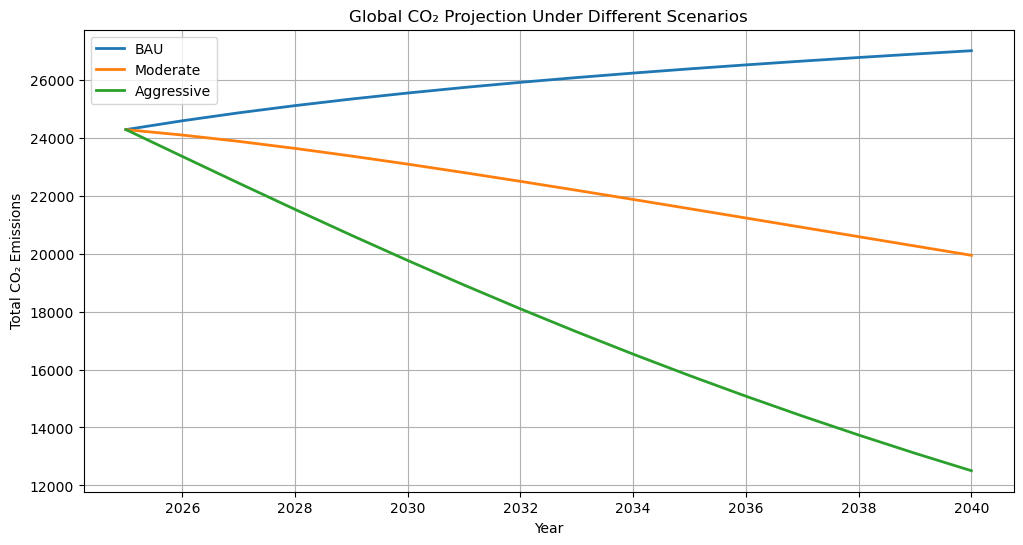

In [41]:
plt.figure(figsize=(12,6))

colors = {
    "BAU": "blue",
    "Moderate": "orange",
    "Aggressive": "green"
}

for scenario in ["BAU", "Moderate", "Aggressive"]:

    data = global_projection[
        global_projection["Scenario"] == scenario
    ]

    plt.plot(
        data["Year"],
        data["CO2_Projected"],
        linewidth=2,
        label=scenario
    )

plt.title(
    "Global CO₂ Projection Under Different Scenarios"
)

plt.xlabel("Year")

plt.ylabel("Total CO₂ Emissions")

plt.grid(True)

plt.legend()

plt.show()

In [42]:
scenario_df.to_csv(
    "data/scenario_projections.csv",
    index=False
)

impact_summary.to_csv(
    "data/scenario_impact_summary.csv",
    index=False
)

print("Scenario outputs saved successfully.")

Scenario outputs saved successfully.


# 7. Week 5 Conclusion

In this notebook, scenario analysis was performed to explore how different policy interventions could influence future CO₂ emission trajectories. Using the ETS(A,Ad,N) baseline forecast developed in Week 4, three scenarios were evaluated: Business As Usual (BAU), Moderate Mitigation (2% annual reduction), and Aggressive Mitigation (5% annual reduction).

Scenario-specific projections were generated for each country from 2025 to 2040, followed by comparative visualizations and cumulative emission analysis. The results showed that while the BAU scenario continued along the baseline forecast, the Moderate and Aggressive mitigation scenarios progressively reduced emissions due to the compounded annual reduction rates. The differences between the scenarios became increasingly significant over time, highlighting the long-term benefits of sustained emission reduction strategies.

Overall, this analysis demonstrates how scenario planning can complement forecasting by illustrating the potential outcomes of different policy choices. Although the scenarios are illustrative and not policy-calibrated, they provide valuable insights into how varying mitigation efforts can affect future greenhouse gas emissions.